# Figure 4 - Age subgroups

Slope (A) and measurement noise $w_m$ (B) across young/old Control and MS subgroups (split at the cohort median age), with FDR-corrected pairwise comparisons.

Reads `data/fig_subject_level.csv` (run `fit_all_subjects.py` first) and saves `results/figures/Figure4.{pdf,png}`.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / "mstiming").exists() else _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mstiming import config, plotting, stats

font = plotting.publication_style()
for pth, script in [(config.FIG_SUBJECT_LEVEL_CSV, "fit_all_subjects.py")]:
    if not pth.exists():
        raise FileNotFoundError(f"Missing {pth.name} -- run: python run_fits/{script}")

df_sub = pd.read_csv(config.FIG_SUBJECT_LEVEL_CSV)
df_sub["Group"] = pd.Categorical(df_sub["Group"], ["Control", "MS"])
print(f"font={font} | N Control={(df_sub.Group=='Control').sum()} N MS={(df_sub.Group=='MS').sum()}")

# Split each group at the cohort median age into young / old subgroups.
median_age  = df_sub["Age"].median()
df_CN_young = df_sub[(df_sub.Group == "Control") & (df_sub.Age <  median_age)]
df_CN_old   = df_sub[(df_sub.Group == "Control") & (df_sub.Age >= median_age)]
df_MS_young = df_sub[(df_sub.Group == "MS")      & (df_sub.Age <  median_age)]
df_MS_old   = df_sub[(df_sub.Group == "MS")      & (df_sub.Age >= median_age)]
print(f"median age = {median_age} | "
      f"CN young/old = {len(df_CN_young)}/{len(df_CN_old)}, "
      f"MS young/old = {len(df_MS_young)}/{len(df_MS_old)}")


font=Gill Sans | N Control=140 N MS=79
median age = 35.0 | CN young/old = 74/66, MS young/old = 32/47


## Subgroup comparisons (FDR-BH)

In [2]:
# Six pairwise subgroup comparisons, Benjamini-Hochberg FDR corrected together.
pairs = [("CN_young", "CN_old"), ("CN_young", "MS_young"), ("CN_young", "MS_old"),
         ("CN_old", "MS_old"),   ("CN_old", "MS_young"),   ("MS_young", "MS_old")]

def posthoc(v):
    samples = {"CN_young": df_CN_young[v], "CN_old": df_CN_old[v],
               "MS_young": df_MS_young[v], "MS_old": df_MS_old[v]}
    return stats.fdr_posthoc(samples, pairs)

PADJ_slope = posthoc("cdfReg_slope")
PADJ_wm    = posthoc("timeWm_BLS_Mod")
print("FDR-BH adjusted p (plotted brackets):")
for lbl, d in [("slope", PADJ_slope), ("wm", PADJ_wm)]:
    print(f"  {lbl}: YoungCN vs OldCN = {d['CN_young|CN_old']:.4f} | "
          f"YoungCN vs OldMS = {d['CN_young|MS_old']:.4f}")


FDR-BH adjusted p (plotted brackets):
  slope: YoungCN vs OldCN = 0.0292 | YoungCN vs OldMS = 0.0199
  wm: YoungCN vs OldCN = 0.0142 | YoungCN vs OldMS = 0.0010


## Figure

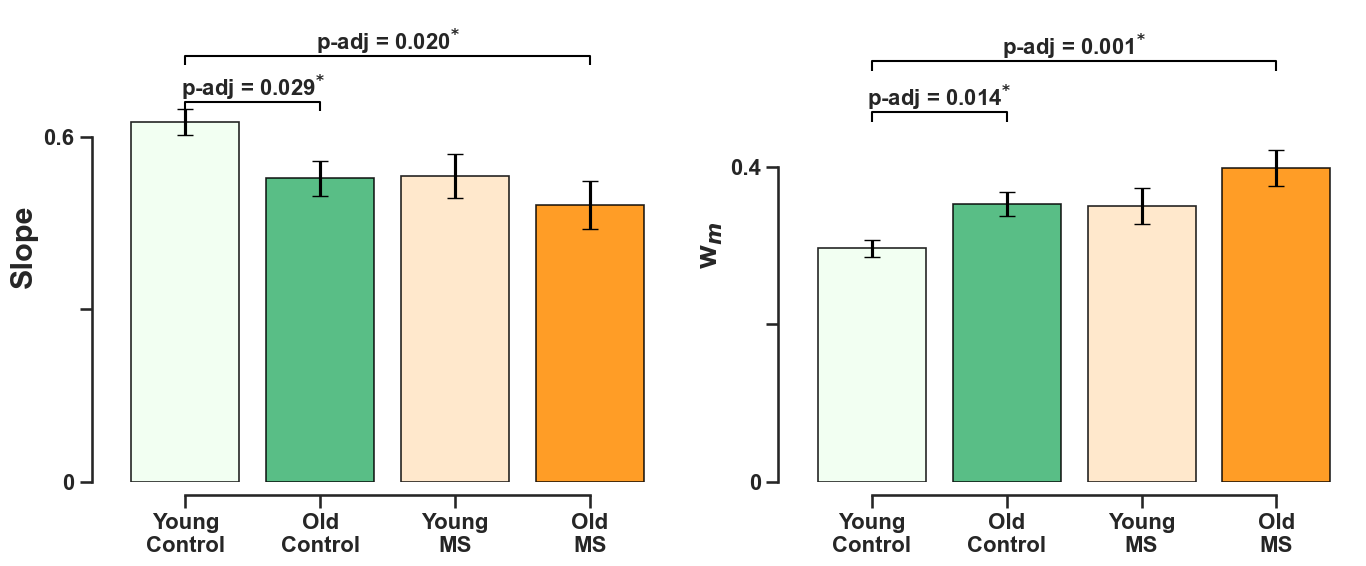

In [3]:
def mean_sem(series):
    s = series.dropna(); return s.mean(), s.std(ddof=1) / np.sqrt(len(s))

groups  = ["Young\nControl", "Old\nControl", "Young\nMS", "Old\nMS"]
palette = ['honeydew', 'mediumseagreen', 'bisque', 'darkorange']
subsets = (df_CN_young, df_CN_old, df_MS_young, df_MS_old)

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# (A) Slope
means, errs = zip(*[mean_sem(df["cdfReg_slope"]) for df in subsets])
ax[0].bar(groups, means, yerr=errs, capsize=6, alpha=0.85,
          color=palette, edgecolor="black", linewidth=1.2)
ax[0].set_ylabel('Slope', fontsize=22); ax[0].set_xlabel('')
ax[0].set_yticks([0.0, 0.3, 0.6]); ax[0].set_yticklabels(['0', '', '0.6'])
ax[0].tick_params(axis='x', labelsize=16); ax[0].tick_params(axis='y', labelsize=16)
ax[0].set_ylim(0, 0.82)
sns.despine(ax=ax[0], offset=10, trim=True)
plotting.sig_bar(ax[0], 0, 1, 0.66, PADJ_slope["CN_young|CN_old"], adj=True, fontsize=16, lw=1.5)
plotting.sig_bar(ax[0], 0, 3, 0.74, PADJ_slope["CN_young|MS_old"], adj=True, fontsize=16, lw=1.5)

# (B) w_m
means, errs = zip(*[mean_sem(df["timeWm_BLS_Mod"]) for df in subsets])
ax[1].bar(groups, means, yerr=errs, capsize=6, alpha=0.85,
          color=palette, edgecolor="black", linewidth=1.2)
ax[1].set_ylabel(r'w$_{m}$', fontsize=22); ax[1].set_xlabel('')
ax[1].set_yticks([0.0, 0.2, 0.4]); ax[1].set_yticklabels(['0', '', '0.4'])
ax[1].tick_params(axis='x', labelsize=16); ax[1].tick_params(axis='y', labelsize=16)
ax[1].set_ylim(0, 0.60)
sns.despine(ax=ax[1], offset=10, trim=True)
plotting.sig_bar(ax[1], 0, 1, 0.47, PADJ_wm["CN_young|CN_old"], adj=True, fontsize=16, lw=1.5)
plotting.sig_bar(ax[1], 0, 3, 0.535, PADJ_wm["CN_young|MS_old"], adj=True, fontsize=16, lw=1.5)

plt.tight_layout()
config.FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIG_DIR / "Figure4.png", dpi=300)
fig.savefig(config.FIG_DIR / "Figure4.pdf", format="pdf", bbox_inches="tight")
plt.show()
